## Koopman Cart Pole Learning

This notebook trains an RL policy on Cart Pole, saving the model after specific lengths of training and fitting a Koopman with control model to the dynamics. The properties of the fit Koopman with control models are assessed, as a function of training. These steps are done $n_{init}$ rounds to have sufficient statistics

In [301]:
import os
os.chdir('/Users/wredman/Documents/GitHub/Koopman4RL/')

import numpy as np
from stable_baselines3.ppo import PPO
from stable_baselines3.a2c import A2C
from stable_baselines3 import DDPG
from stable_baselines3 import SAC
from stable_baselines3 import TD3
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from pydmd.dmdc import DMDc

from utils import generate_imitation_training_data, concatenate_episodes
import matplotlib.pyplot as plt

### Create Cart Pole environment

Here we create the Cart Pole environment.

In [309]:
task = "LunarLander-v3"  #"CartPole-v1" # "Acrobot-v1" #"LunarLander-v3"
env = make_vec_env(task,
                   n_envs=4) #CartPole: 1 #Acrobot: 4 #LunarLander: 4

### Training and saving the RL model

Now we train the RL model on varying numbers of training steps and save the resulting model.

In [310]:
n_init = 25
RL_algo = "PPO"
training_epochs = [0, 10000, 20000, 30000, 40000, 50000] #CartPole: [0, 200, 400, 600, 800, 1000] #Acrobot: [0, 2000, 4000, 6000, 8000, 10000] # LunarLander: [0, 10000, 20000, 30000, 40000, 50000]
training_save_path = '/Users/wredman/Documents/GitHub/Koopman4RL/Models/' + RL_algo + '/'

In [311]:
for init in range(n_init):
    if RL_algo == "PPO":
        model = PPO("MlpPolicy", env=env, verbose=False)
    elif RL_algo == "A2C":
        model = A2C("MlpPolicy", env=env, verbose=False)
    elif RL_algo == "SAC":
        model = SAC("MlpPolicy", env=env, verbose=False)
    elif RL_algo == "TD3":
        model = TD3("MlpPolicy", env=env, verbose=False)
    elif RL_algo == "DDPG":
        model = DDPG("MlpPolicy", env=env, verbose=False)
    elif RL_algo == "DQN":
        model = DQN("MlpPolicy", env=env, verbose=False)

    model.learn(total_timesteps=training_epochs[0])
    model.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[0]))

    for tt in range(1, len(training_epochs)):
        print("Training epoch: " + str(training_epochs[tt]))
        model.learn(total_timesteps=(training_epochs[tt] - training_epochs[tt - 1]))
        model.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]))

### Loading RL models and fitting Koopman with control models

Having trained and saved the RL models, we now load them and fit Koopman with control models to them.

In [312]:
 env = make_vec_env(task, n_envs=1)

for init in range(n_init):
    print(init)

    for training_epoch in training_epochs:
        # Loading model
        if RL_algo == "PPO":
            model = PPO.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch))
        elif RL_algo == "A2C":
            model = A2C.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch))
        elif RL_algo == "SAC":
            model = SAC.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch))
        elif RL_algo == "DQN":
            model = DQN.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch))

        # Generating example trajectories with learned model
        training_data = generate_imitation_training_data(model, env,
                                                         n_episodes= 100,
                                                         max_ep_length = 1000) #CartPole: 200 #Acrobot: 500 #LunarLander = 1000
        training_observations, training_actions, training_rewards = training_data['observations'], training_data['actions'], training_data['rewards']

        # Saving rewards
        np.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch) + "-rewards.npy", training_rewards)

        # Concatenating states and actions
        X1, X2, U = concatenate_episodes(episodes_list=training_observations,
                                      actions_list=training_actions,
                                      n_time_delays = 5, #CartPole: 4  #Acrobot: 5 #LunarLander: 5
                                      n_actions = 4, #CartPole: 2 #Acrobot: 3 #LunarLander: 4
                                      discrete = True
                                      )

        time_lag = X2.shape[-1]
        X = np.hstack([X1, X2])

        # Fitting Koopman with control model
        dmdc = DMDc(svd_rank= -1,
                    svd_rank_omega = 0.99, #CartPole: 0.95 #Acrobot: 0.99 #LunarLander: 0.99
                    lag=time_lag)
        dmdc.fit(X, U)

        A_tilde = dmdc._Atilde._Atilde
        B_hat = dmdc.B

        # Saving Koopman model
        np.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch) + "-A_tilde.npy", A_tilde)
        np.save(training_save_path + task + "_init-" + str(init) + "_epochs-"  + str(training_epoch) + "-B_hat.npy", B_hat)

        # Extracting Koopman eigenvalues
        model_eigs = dmdc.eigs

        # Saving Koopman eigenvalues
        np.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch) + "-eigenvalues.npy", model_eigs)

        # Reconstructing data
        spatial_dim = np.vstack(training_observations[0]).T.shape[0]
        X_hat = dmdc.reconstructed_data()
        X2_hat = X_hat[:spatial_dim, time_lag:]
        X2_true = X2[:spatial_dim, : ]

        # Assessing reconstruction error
        reconstruction_residuals = X2_true - X2_hat.real

        # Saving reconstruction error
        np.save(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epoch) + "-reconstruction-residuals.npy", reconstruction_residuals)


0


100%|██████████| 100/100 [00:01<00:00, 64.18it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 351092.15625. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 36.40it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 681374.3125. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 43.13it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 445689.875. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:05<00:00, 16.69it/s]
/Users/wredman/Do

1


100%|██████████| 100/100 [00:01<00:00, 67.43it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 440129.84375. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:01<00:00, 55.90it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 466354.84375. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 44.66it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 372810.40625. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:04<00:00, 23.84it/s]
/Users/wredman

2


...

100%|██████████| 100/100 [00:01<00:00, 63.20it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 330400.59375. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 44.71it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 424536.5. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 39.66it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 381517.9375. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:05<00:00, 18.17it/s]
/Users/wredman/Docu

23


100%|██████████| 100/100 [00:02<00:00, 44.43it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 386282.1875. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:01<00:00, 54.85it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 576853.75. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 43.11it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 372708.0625. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:04<00:00, 22.35it/s]
/Users/wredman/Docu

24


100%|██████████| 100/100 [00:02<00:00, 49.51it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 370954.34375. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 41.74it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 436017.65625. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:02<00:00, 35.56it/s]
/Users/wredman/Documents/GitHub/Koopman4RL/.venv/lib/python3.9/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 588943.6875. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
100%|██████████| 100/100 [00:05<00:00, 18.25it/s]
/Users/wredman/

In [313]:
max_eig_norm = np.zeros((len(training_epochs), n_init))
average_reward = np.zeros((len(training_epochs), n_init))
average_reconstruction_MSE = np.zeros((len(training_epochs), n_init))

for init in range(n_init):
    for tt in range(len(training_epochs)):
        eigs = np.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-eigenvalues.npy")
        print(eigs)
        print(np.abs(eigs))
        max_eig_norm[tt, init] = np.max(np.abs(eigs))#np.median(np.abs(eigs)) #np.abs(1 - np.max(np.real(eigs)))

        rewards = np.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-rewards.npy")
        average_reward[tt, init] = np.median(rewards)

        reconstruction_residuals = np.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-reconstruction-residuals.npy")
        average_reconstruction_MSE[tt, init] = np.median(np.mean((reconstruction_residuals**2), axis = 0))

[ 9.69422842e-01+0.00000000e+00j  1.03531394e+00+1.21293000e-02j
  1.03531394e+00-1.21293000e-02j  1.02451482e+00+0.00000000e+00j
  9.98864515e-01+0.00000000e+00j  1.00308702e+00+0.00000000e+00j
 -1.20828748e-04+0.00000000e+00j  8.38809526e-05+0.00000000e+00j
  6.94688285e-06+0.00000000e+00j  1.19163006e-16+3.06630185e-16j
  1.19163006e-16-3.06630185e-16j  3.59930666e-17+0.00000000e+00j
 -6.07302407e-18+4.75914913e-18j -6.07302407e-18-4.75914913e-18j
  3.76634083e-18+2.73240903e-18j  3.76634083e-18-2.73240903e-18j
  4.67549327e-18+6.08954187e-19j  4.67549327e-18-6.08954187e-19j
 -2.08012073e-18+2.18307866e-19j -2.08012073e-18-2.18307866e-19j
 -5.44564944e-19+6.84426645e-19j -5.44564944e-19-6.84426645e-19j
  1.27808395e-19+6.45789079e-19j  1.27808395e-19-6.45789079e-19j
  1.69718732e-19+0.00000000e+00j  5.76509739e-20+0.00000000e+00j
 -2.82039198e-21+2.27261244e-20j -2.82039198e-21-2.27261244e-20j
 -2.47618492e-21+0.00000000e+00j  1.63076713e-21+0.00000000e+00j
  6.49231346e-22+0.000000

### Examining properties of the controlability, as a function of training

We also examine properties of the controlability of the system. For now, we just look at the rank.

In [314]:
control_rank = np.zeros((len(training_epochs), n_init))

for init in range(n_init):
    for tt in range(len(training_epochs)):
        A = np.load(training_save_path + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-A_tilde.npy")
        B = np.load(training_save_path + task + "_init-" + str(init) + "_epochs-"  + str(training_epochs[tt]) + "-B_hat.npy")

        C = B
        for ii in range(1, np.shape(A)[0]):
            C = np.concatenate((C, A**ii @ B), 1)
        control_rank[tt, init] = np.linalg.matrix_rank(C)

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_46528/345204427.py:10: RuntimeWarning: divide by zero encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_46528/345204427.py:10: RuntimeWarning: overflow encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_46528/345204427.py:10: RuntimeWarning: invalid value encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)


### Plotting

Now we plot the reward and spectral properties, as a function of training time.

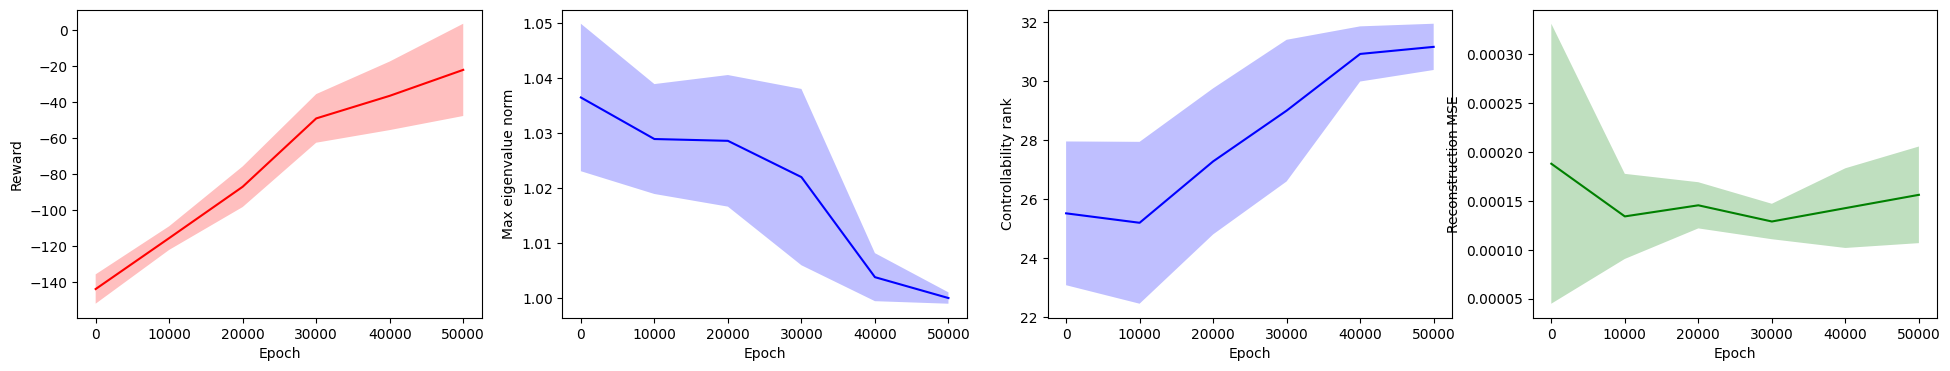

In [315]:
results_save_path = '/Users/wredman/Documents/GitHub/Koopman4RL/results/' + RL_algo + '/'

plt.figure(figsize=(24, 4))

plt.subplot(1, 4, 1)
plt.fill_between(training_epochs, np.mean(average_reward, axis = 1) - np.std(average_reward, axis = 1), np.mean(average_reward, axis = 1) + np.std(average_reward, axis = 1), alpha = 0.25, facecolor = 'r')
plt.plot(training_epochs, np.mean(average_reward, axis = 1), 'r-')
plt.xlabel('Epoch')
plt.ylabel('Reward')

plt.subplot(1, 4, 2)
plt.fill_between(training_epochs, np.mean(max_eig_norm, axis = 1) - np.std(max_eig_norm, axis = 1), np.mean(max_eig_norm, axis = 1) + np.std(max_eig_norm, axis = 1), alpha = 0.25, facecolor = 'b')
plt.plot(training_epochs, np.mean(max_eig_norm, axis = 1), 'b-')
plt.xlabel('Epoch')
plt.ylabel('Max eigenvalue norm')
#plt.ylim([0, 1])

plt.subplot(1, 4, 3)
plt.fill_between(training_epochs, np.mean(control_rank, axis = 1) - np.std(control_rank, axis = 1), np.mean(control_rank, axis = 1) + np.std(control_rank, axis = 1), alpha = 0.25, facecolor = 'b')
plt.plot(training_epochs, np.mean(control_rank, axis = 1), 'b-')
plt.xlabel('Epoch')
plt.ylabel('Controllability rank')

plt.subplot(1, 4, 4)
plt.fill_between(training_epochs, np.mean(average_reconstruction_MSE, axis = 1) - np.std(average_reconstruction_MSE, axis = 1), np.mean(average_reconstruction_MSE, axis = 1) + np.std(average_reconstruction_MSE, axis = 1), alpha = 0.25, facecolor = 'g')
plt.plot(training_epochs, np.mean(average_reconstruction_MSE, axis = 1), 'g-')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')
#plt.ylim(0, 1)

plt.savefig(results_save_path + task + '-summary-results.png')